In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import *

In [2]:
df = pd.read_csv("/content/students_data.csv")
df.head(15)

,study_hours,attendance,assignments_completed,previous_score,sleep_hours,result
0,7,50,8,50,8,1
1,4,60,4,99,5,1
2,8,77,0,76,8,1
3,5,74,9,75,5,1
4,7,99,9,74,8,1
5,3,72,0,58,6,0
6,7,80,1,59,6,0
7,8,79,5,96,6,1
8,5,91,8,57,6,1
9,4,84,7,86,4,1


In [3]:
df.shape

(200, 6)

In [4]:
df.columns

Index(['study_hours', 'attendance', 'assignments_completed', 'previous_score',
       'sleep_hours', 'result'],
      dtype='object')

In [5]:
df.describe()

,study_hours,attendance,assignments_completed,previous_score,sleep_hours,result
count,200.00000,200.000000,200.00000,200.000000,200.00000,200.000000
mean,5.07000,76.410000,4.60500,69.705000,5.94500,0.500000
std,2.63435,13.964488,3.00234,17.829961,1.42553,0.501255
min,1.00000,50.000000,0.00000,40.000000,4.00000,0.000000
25%,3.00000,66.000000,2.00000,54.000000,5.00000,0.000000
50%,5.00000,77.000000,4.00000,69.000000,6.00000,0.500000
75%,7.00000,87.000000,7.00000,87.000000,7.00000,1.000000
max,9.00000,99.000000,9.00000,99.000000,8.00000,1.000000


In [6]:
df.isnull().sum()

,0
study_hours,0
attendance,0
assignments_completed,0
previous_score,0
sleep_hours,0
result,0


In [8]:
df["result"].value_counts()

,count
result,
1,100
0,100


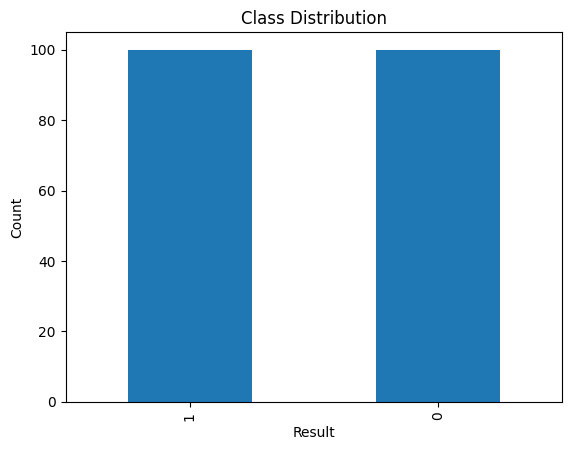

In [9]:
df["result"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Result")
plt.ylabel("Count")
plt.show()

In [11]:
X = df.drop("result", axis=1)
y = df["result"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (160, 5)
X_test : (40, 5)
y_train: (160,)
y_test : (40,)


In [13]:
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=7)

In [14]:
svm_model = SVC(kernel="rbf", C=2, gamma="scale")
svm_model.fit(X_train, y_train)

SVC(C=2)

In [15]:
dt_model = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, random_state=42)

In [16]:
y_pred_knn = knn_model.predict(X_test)
y_pred_svm = svm_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)

In [18]:
def classifier(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred)
    }

In [20]:
results = []
results.append(classifier("KNN", y_test, y_pred_knn))
results.append(classifier("SVM", y_test, y_pred_svm))
results.append(classifier("Decision Tree", y_test, y_pred_dt))

results_df = pd.DataFrame(results)
print(results_df)

           Model  Accuracy  Precision  Recall  F1 Score
0            KNN     0.725   0.714286    0.75  0.731707
1            SVM     0.775   0.789474    0.75  0.769231
2  Decision Tree     0.800   0.875000    0.70  0.777778


In [21]:
print("KNN Classification Report\n")
print(classification_report(y_test, y_pred_knn))

print("\nSVM Classification Report\n")
print(classification_report(y_test, y_pred_svm))

print("\nDecision Tree Classification Report\n")
print(classification_report(y_test, y_pred_dt))

KNN Classification Report

              precision    recall  f1-score   support

           0       0.74      0.70      0.72        20
           1       0.71      0.75      0.73        20

    accuracy                           0.72        40
   macro avg       0.73      0.72      0.72        40
weighted avg       0.73      0.72      0.72        40


SVM Classification Report

              precision    recall  f1-score   support

           0       0.76      0.80      0.78        20
           1       0.79      0.75      0.77        20

    accuracy                           0.78        40
   macro avg       0.78      0.78      0.77        40
weighted avg       0.78      0.78      0.77        40


Decision Tree Classification Report

              precision    recall  f1-score   support

           0       0.75      0.90      0.82        20
           1       0.88      0.70      0.78        20

    accuracy                           0.80        40
   macro avg       0.81      0.80  

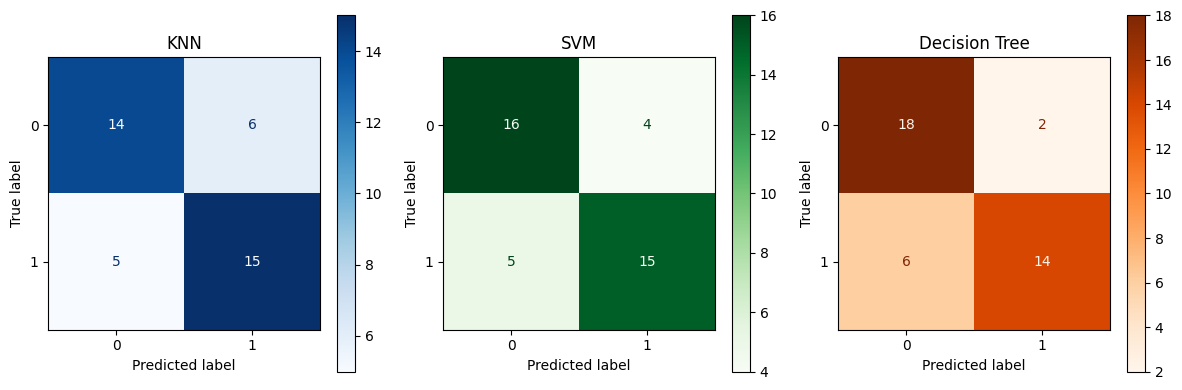

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_knn)).plot(ax=axes[0], cmap='Blues', colorbar=True)
axes[0].set_title("KNN")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_svm)).plot(ax=axes[1], cmap='Greens', colorbar=True)
axes[1].set_title("SVM")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_dt)).plot(ax=axes[2], cmap='Oranges', colorbar=True)
axes[2].set_title("Decision Tree")

plt.tight_layout()
plt.show()

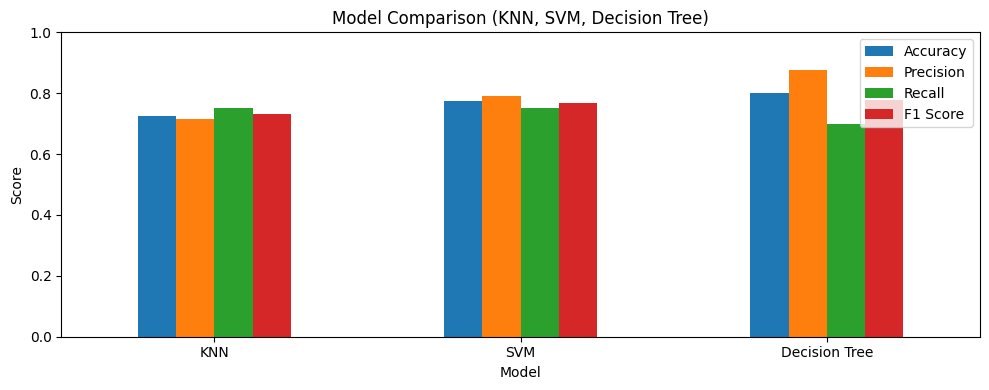

In [38]:
import matplotlib.pyplot as plt

results_plot = results_df.set_index("Model")

results_plot.plot(kind="bar", figsize=(10, 4))

plt.title("Model Comparison (KNN, SVM, Decision Tree)")
plt.ylabel("Score")
plt.ylim(0, 1)


plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [40]:
#conclusion
best_model = results_df.sort_values("Accuracy", ascending=False).iloc[0]
print("Best classification model based on Accuracy:")
print(best_model)

Best classification model based on Accuracy:
Model        Decision Tree
Accuracy               0.8
Precision            0.875
Recall                 0.7
F1 Score          0.777778
Name: 2, dtype: object


In [41]:
# Conclusion
best_model = results_df.sort_values(by="Accuracy", ascending=False).iloc[0]

print("Best Model (based on Accuracy):")
print("Model Name:", best_model["Model"])
print("Accuracy  :", best_model["Accuracy"])

Best Model (based on Accuracy):
Model Name: Decision Tree
Accuracy  : 0.8
